# Experiment Analysis

In [1]:
import pandas as pd
import time
import matplotlib.pyplot as plt

pd.set_option('display.max_columns',None)
#exp_name = 'e_100K'
exp_name = 'e_1M'

In [2]:

df = pd.read_parquet(f'{exp_name}.parquet')
df.head()

,experiment,val_loss,val_recall,val_precision,val_ndcg,test_loss,test_recall,test_precision,test_ndcg,optim_time,train_time,infer_time,users,items,train_edges,val_edges,test_edges,n_layers,embedding_dim,lr,lambda_val,batch_size,optimizer,train_losses,val_losses
0,e_1M_full,0.264009,0.067700,0.039709,0.061549,0.262678,0.070726,0.043242,0.065340,2767.445121,77.977364,0.847468,6039,3606,669182,83648,83648,1,256,0.022158,0.002118,1890,RMSprop,"[0.7060106992721558, 0.3961314558982849, 0.346...","[0.6423912644386292, 0.3751087784767151, 0.347..."
1,e_1M_1c1dcs,0.281977,0.063397,0.018060,0.042661,0.281163,0.068037,0.019252,0.045514,1914.538283,51.925179,0.781144,6032,3603,167284,83648,83648,1,256,0.001706,0.000005,660,RMSprop,"[0.6813427805900574, 0.2557334303855896, 0.202...","[0.6696547269821167, 0.4170322120189667, 0.396..."
2,e_1M_1c1dcs_rand1,0.349197,0.027210,0.016994,0.024363,0.350946,0.026502,0.017292,0.024226,1241.301120,62.636469,0.776076,6021,3363,167284,83648,83648,2,256,0.015942,0.002539,2837,RMSprop,"[0.7069007754325867, 0.2978862524032593, 0.280...","[0.6855096220970154, 0.365547776222229, 0.3645..."
3,e_1M_1c1dcs_rand2,0.384663,0.036209,0.024238,0.033338,0.387211,0.038592,0.025097,0.035093,1455.480214,56.397563,0.798101,6028,3371,167284,83648,83648,4,96,0.000054,0.000145,2111,RMSprop,"[0.6926766633987427, 0.6904538869857788, 0.683...","[0.6917889714241028, 0.6895594596862793, 0.682..."
4,e_1M_1c1dcs_rand3,0.326388,0.033298,0.023908,0.031166,0.328328,0.033148,0.022943,0.030620,1655.630766,49.528152,0.786229,6026,3374,167284,83648,83648,1,256,0.000181,0.000006,1431,Adam,"[0.6819039583206177, 0.6786507368087769, 0.674...","[0.6711055040359497, 0.6703928709030151, 0.668..."


In [3]:
key = ['experiment']
val_features = ['val_loss','val_recall','val_precision','val_ndcg' ]
test_features = ['test_loss','test_recall','test_precision','test_ndcg']
time_features = ['optim_time','train_time','infer_time']
edge_features =  ['train_edges']
numerical_features = val_features + test_features
categorical_features = ['n_layers','embedding_dim','lr','lambda_val','batch_size', 'optimizer']

random_experiments_stats = df.copy()
random_experiments_stats = random_experiments_stats[key + numerical_features + time_features + edge_features + categorical_features]
random_experiments_stats['experiment'] = random_experiments_stats['experiment'].apply(lambda x: x[len(exp_name)+1:-1] if '_rand' in x else x[len(exp_name)+1:])
random_experiments_stats

,experiment,val_loss,val_recall,val_precision,val_ndcg,test_loss,test_recall,test_precision,test_ndcg,optim_time,train_time,infer_time,train_edges,n_layers,embedding_dim,lr,lambda_val,batch_size,optimizer
0,full,0.264009,0.067700,0.039709,0.061549,0.262678,0.070726,0.043242,0.065340,2767.445121,77.977364,0.847468,669182,1,256,0.022158,0.002118,1890,RMSprop
1,1c1dcs,0.281977,0.063397,0.018060,0.042661,0.281163,0.068037,0.019252,0.045514,1914.538283,51.925179,0.781144,167284,1,256,0.001706,0.000005,660,RMSprop
2,1c1dcs_rand,0.349197,0.027210,0.016994,0.024363,0.350946,0.026502,0.017292,0.024226,1241.301120,62.636469,0.776076,167284,2,256,0.015942,0.002539,2837,RMSprop
3,1c1dcs_rand,0.384663,0.036209,0.024238,0.033338,0.387211,0.038592,0.025097,0.035093,1455.480214,56.397563,0.798101,167284,4,96,0.000054,0.000145,2111,RMSprop
4,1c1dcs_rand,0.326388,0.033298,0.023908,0.031166,0.328328,0.033148,0.022943,0.030620,1655.630766,49.528152,0.786229,167284,1,256,0.000181,0.000006,1431,Adam
5,1c1dcs_rand,0.370632,0.027045,0.017383,0.024797,0.372490,0.027751,0.018305,0.025522,783.708797,48.817294,0.762612,167284,2,128,0.010347,0.006907,2488,Adam
6,1c1dcs_rand,0.327134,0.025088,0.016139,0.022306,0.330753,0.027441,0.016844,0.024173,1416.563935,48.781710,0.776837,167284,2,128,0.011361,0.001720,1793,RMSprop
7,1c2dcs,0.328907,0.045843,0.012779,0.029652,0.325847,0.045884,0.013051,0.030317,2676.751763,55.827746,0.753393,188411,2,128,0.001853,0.000006,3712,RMSprop
8,1c2dcs_rand,0.344689,0.030719,0.018670,0.026923,0.342155,0.031431,0.019302,0.027594,1400.748524,49.833283,0.783985,188411,2,128,0.036131,0.003479,1889,RMSprop
9,1c2dcs_rand,0.567090,0.036067,0.023663,0.032944,0.567053,0.040348,0.025122,0.036311,1362.429758,51.856171,0.805978,188411,1,256,0.000044,0.000002,2680,Adam


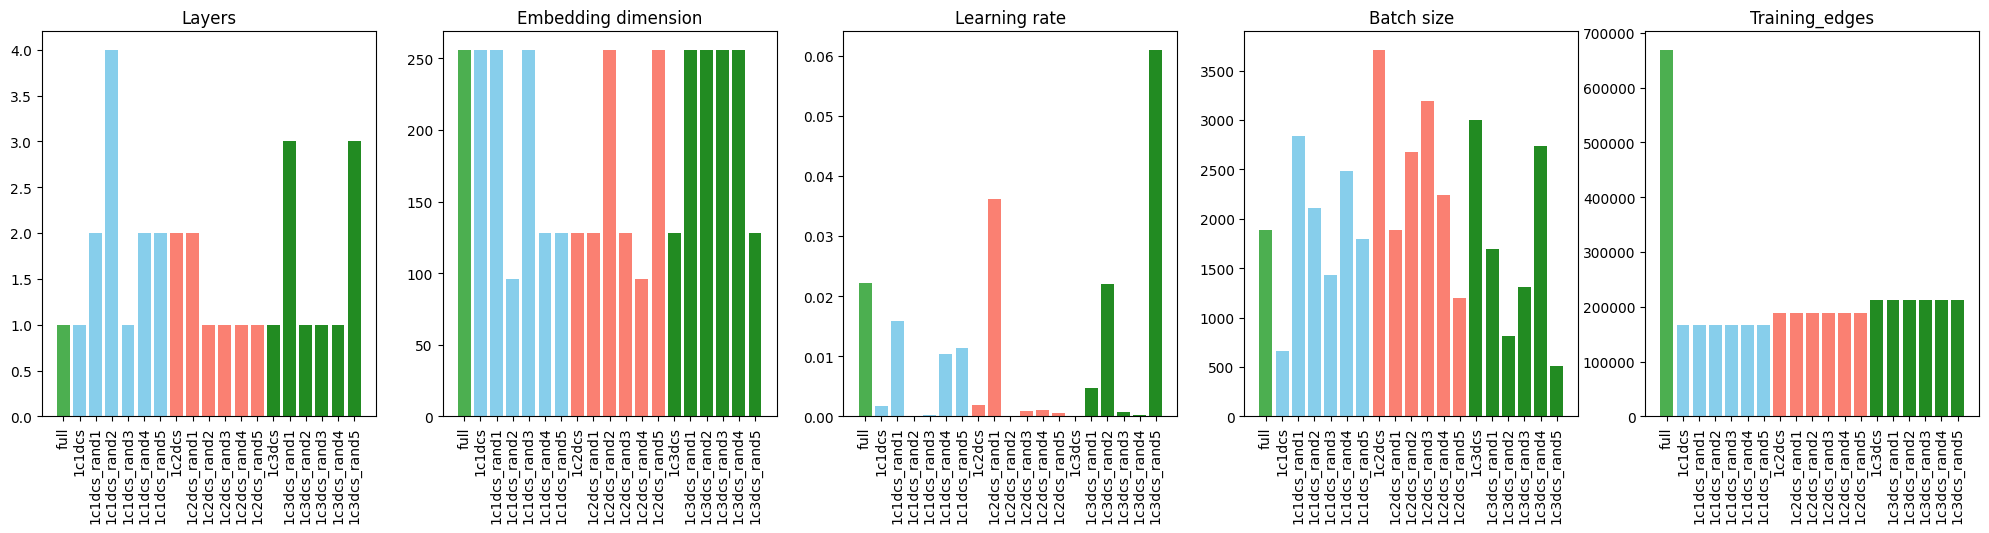

In [13]:
colors={'full':'#4CAF50', '1c1dcs':'skyblue','1c2dcs':'salmon','1c3dcs':'forestgreen'}

def set_color(text):
    for col in colors.keys():
        if col in text:
            return(colors[col])
            

new_df = df.copy()
new_df['experiment'] = new_df['experiment'].apply(lambda x: x[len(exp_name)+1:])
new_df['color'] = new_df['experiment'].apply(set_color)


plots=['n_layers','embedding_dim','lr','batch_size','train_edges']
titles=['Layers', 'Embedding dimension', 'Learning rate', 'Batch size','Training_edges']


plt.figure(figsize=(25,5))

cols = ['n_layers','embedding_dim','lr','batch_size']

for i,metric in enumerate(plots):
    plt.subplot(1,len(plots),i+1)

    plt.bar(new_df['experiment'], new_df[metric] , color=new_df['color'], capsize=5)
    plt.title(titles[i])
    plt.xticks(rotation=90)

plt.show()


In [6]:
aggregations = { x : ['mean','std'] for x in numerical_features + time_features}
aggregations.update({ x : ['mean'] for x in edge_features} )
aggregations.update({ x : ['unique'] for x in categorical_features} )


result = random_experiments_stats.groupby(key, as_index=False).agg(aggregations)
result.columns = ["_".join(col).strip() for col in result.columns.values]
result.columns = [ x[:-1] if x[-1]== '_' else x for x in result.columns]
result.fillna(0, inplace=True)
result

,experiment,val_loss_mean,val_loss_std,val_recall_mean,val_recall_std,val_precision_mean,val_precision_std,val_ndcg_mean,val_ndcg_std,test_loss_mean,test_loss_std,test_recall_mean,test_recall_std,test_precision_mean,test_precision_std,test_ndcg_mean,test_ndcg_std,optim_time_mean,optim_time_std,train_time_mean,train_time_std,infer_time_mean,infer_time_std,train_edges_mean,n_layers_unique,embedding_dim_unique,lr_unique,lambda_val_unique,batch_size_unique,optimizer_unique
0,1c1dcs,0.281977,0.000000,0.063397,0.000000,0.018060,0.000000,0.042661,0.000000,0.281163,0.000000,0.068037,0.000000,0.019252,0.000000,0.045514,0.000000,1914.538283,0.000000,51.925179,0.000000,0.781144,0.000000,167284.0,[1],[256],[0.0017064243947338825],[4.6775409147793504e-06],[660],[RMSprop]
1,1c1dcs_rand,0.351602,0.025958,0.029770,0.004738,0.019733,0.003990,0.027194,0.004774,0.353946,0.025757,0.030687,0.005129,0.020096,0.003700,0.027927,0.004800,1310.536966,329.272499,53.232238,6.153820,0.779971,0.013174,167284.0,"[2, 4, 1]","[256, 96, 128]","[0.01594243311234559, 5.421768039843184e-05, 0...","[0.00253945564195761, 0.00014478028584620918, ...","[2837, 2111, 1431, 2488, 1793]","[RMSprop, Adam]"
2,1c2dcs,0.328907,0.000000,0.045843,0.000000,0.012779,0.000000,0.029652,0.000000,0.325847,0.000000,0.045884,0.000000,0.013051,0.000000,0.030317,0.000000,2676.751763,0.000000,55.827746,0.000000,0.753393,0.000000,188411.0,[2],[128],[0.0018525931208548067],[6.253073248221469e-06],[3712],[RMSprop]
3,1c2dcs_rand,0.342802,0.139120,0.034342,0.005833,0.021769,0.002663,0.030885,0.004193,0.341116,0.140368,0.036394,0.007043,0.022646,0.002899,0.032463,0.005310,1172.642488,324.214444,48.856607,4.161990,0.793266,0.012947,188411.0,"[2, 1]","[128, 256, 96]","[0.03613078597167189, 4.4337389800696115e-05, ...","[0.0034794362402148877, 2.0735243008846295e-06...","[1889, 2680, 3189, 2245, 1202]","[RMSprop, Adam]"
4,1c3dcs,0.451110,0.000000,0.082398,0.000000,0.048722,0.000000,0.072356,0.000000,0.453078,0.000000,0.085593,0.000000,0.052762,0.000000,0.078419,0.000000,925.673013,0.000000,48.430204,0.000000,0.859208,0.000000,212879.0,[1],[128],[6.009873405154328e-05],[0.0009680081982663437],[3005],[RMSprop]
5,1c3dcs_rand,0.275661,0.068428,0.033640,0.007398,0.020980,0.004932,0.030061,0.007183,0.275757,0.069119,0.035366,0.009723,0.021799,0.005546,0.031442,0.008098,1692.479598,495.972067,59.797988,12.198788,0.791506,0.015656,212879.0,"[3, 1]","[256, 128]","[0.00466091304818241, 0.021985970300332947, 0....","[9.124854177401622e-06, 0.005434706275695073, ...","[1694, 815, 1306, 2741, 513]","[RMSprop, Adam]"
6,full,0.264009,0.000000,0.067700,0.000000,0.039709,0.000000,0.061549,0.000000,0.262678,0.000000,0.070726,0.000000,0.043242,0.000000,0.065340,0.000000,2767.445121,0.000000,77.977364,0.000000,0.847468,0.000000,669182.0,[1],[256],[0.022157795219346153],[0.0021175731921011984],[1890],[RMSprop]


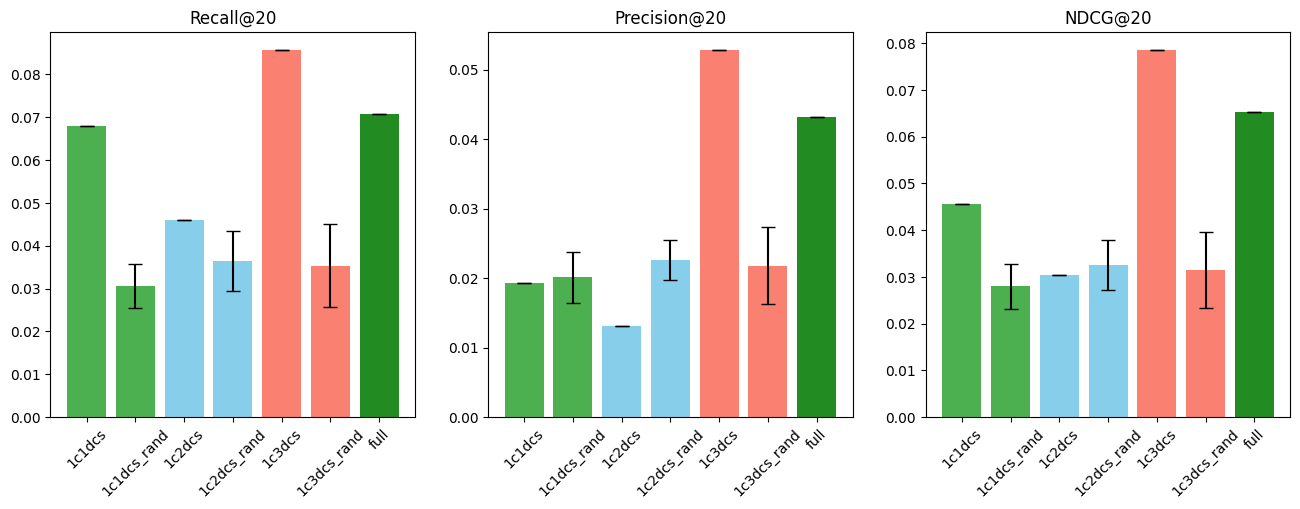

In [7]:
plots=['test_recall','test_precision','test_ndcg']
titles=['Recall@20', 'Precision@20', 'NDCG@20']
colors=[ '#4CAF50','#4CAF50','skyblue','skyblue','salmon','salmon', 'forestgreen']
plt.figure(figsize=(16,5))

for i,metric in enumerate(plots):
    plt.subplot(1,len(plots),i+1)

    plt.bar(result['experiment'], result[metric+'_mean'], yerr=result[metric+'_std'], color=colors, capsize=5)
    plt.title(titles[i])
    plt.xticks(rotation=45)

plt.show()

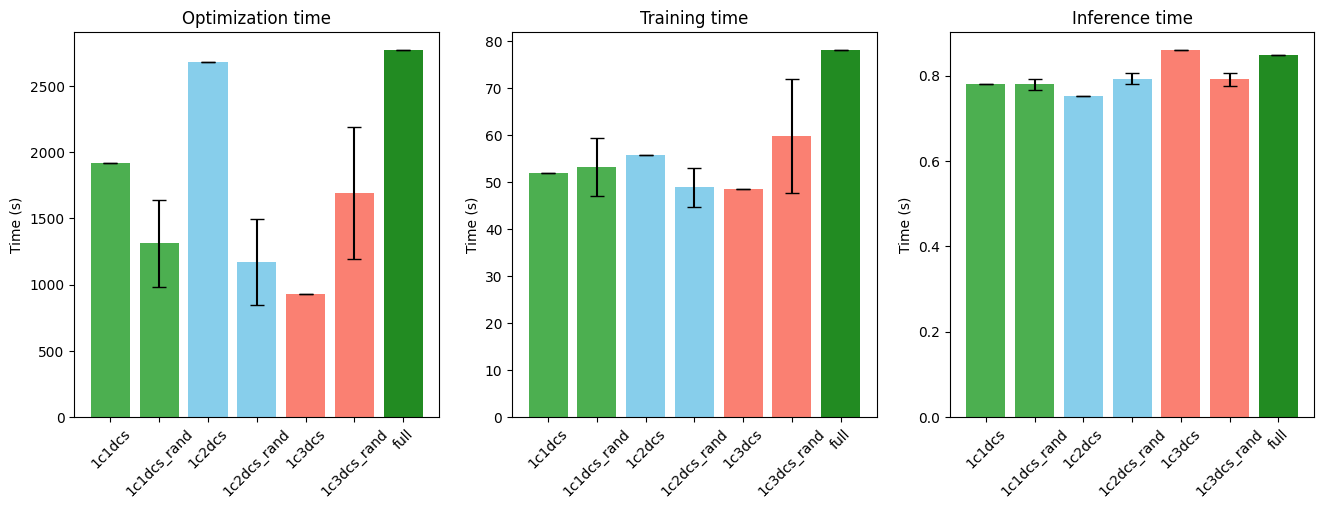

In [8]:
plots=['optim_time','train_time','infer_time']
titles=['Optimization time', 'Training time', 'Inference time']
colors=[ '#4CAF50','#4CAF50','skyblue','skyblue','salmon','salmon', 'forestgreen']
plt.figure(figsize=(16,5))

for i,metric in enumerate(plots):
    plt.subplot(1,len(plots),i+1)

    plt.bar(result['experiment'], result[metric+'_mean'], yerr=result[metric+'_std'], color=colors, capsize=5)
    plt.title(titles[i])
    plt.ylabel('Time (s)')
    plt.xticks(rotation=45)

plt.show()

In [9]:
result_viewable = result.copy()

for col in numerical_features:
    result_viewable[col] = result_viewable[[col+'_mean',col+'_std']].apply(lambda x: '{:,.4f}'.format(x[col+'_mean']) if x[col+'_std'] ==0 else '{:,.4f}'.format(x[col+'_mean']) + ' \u00B1 ' +  '{:,.4f}'.format(x[col+'_std']), axis=1)
    result_viewable.drop([col+'_mean', col+'_std'], axis=1, inplace=True)

for col in time_features:
    result_viewable[col] = result_viewable[[col+'_mean',col+'_std']].apply(lambda x: str(time.strftime("%H:%M:%S", time.gmtime(x[col+'_mean']))) if x[col+'_std'] ==0 else str(time.strftime("%H:%M:%S", time.gmtime(x[col+'_mean']))) + ' \u00B1 ' +  str(time.strftime("%H:%M:%S", time.gmtime(x[col+'_std']))), axis=1)
    result_viewable.drop([col+'_mean', col+'_std'], axis=1, inplace=True)

result_viewable = result_viewable[key + numerical_features + [x +'_mean' for x in edge_features] + time_features + [x +'_unique' for x in categorical_features] ]


In [10]:
result_viewable

,experiment,val_loss,val_recall,val_precision,val_ndcg,test_loss,test_recall,test_precision,test_ndcg,train_edges_mean,optim_time,train_time,infer_time,n_layers_unique,embedding_dim_unique,lr_unique,lambda_val_unique,batch_size_unique,optimizer_unique
0,1c1dcs,0.2820,0.0634,0.0181,0.0427,0.2812,0.0680,0.0193,0.0455,167284.0,00:31:54,00:00:51,00:00:00,[1],[256],[0.0017064243947338825],[4.6775409147793504e-06],[660],[RMSprop]
1,1c1dcs_rand,0.3516 ± 0.0260,0.0298 ± 0.0047,0.0197 ± 0.0040,0.0272 ± 0.0048,0.3539 ± 0.0258,0.0307 ± 0.0051,0.0201 ± 0.0037,0.0279 ± 0.0048,167284.0,00:21:50 ± 00:05:29,00:00:53 ± 00:00:06,00:00:00 ± 00:00:00,"[2, 4, 1]","[256, 96, 128]","[0.01594243311234559, 5.421768039843184e-05, 0...","[0.00253945564195761, 0.00014478028584620918, ...","[2837, 2111, 1431, 2488, 1793]","[RMSprop, Adam]"
2,1c2dcs,0.3289,0.0458,0.0128,0.0297,0.3258,0.0459,0.0131,0.0303,188411.0,00:44:36,00:00:55,00:00:00,[2],[128],[0.0018525931208548067],[6.253073248221469e-06],[3712],[RMSprop]
3,1c2dcs_rand,0.3428 ± 0.1391,0.0343 ± 0.0058,0.0218 ± 0.0027,0.0309 ± 0.0042,0.3411 ± 0.1404,0.0364 ± 0.0070,0.0226 ± 0.0029,0.0325 ± 0.0053,188411.0,00:19:32 ± 00:05:24,00:00:48 ± 00:00:04,00:00:00 ± 00:00:00,"[2, 1]","[128, 256, 96]","[0.03613078597167189, 4.4337389800696115e-05, ...","[0.0034794362402148877, 2.0735243008846295e-06...","[1889, 2680, 3189, 2245, 1202]","[RMSprop, Adam]"
4,1c3dcs,0.4511,0.0824,0.0487,0.0724,0.4531,0.0856,0.0528,0.0784,212879.0,00:15:25,00:00:48,00:00:00,[1],[128],[6.009873405154328e-05],[0.0009680081982663437],[3005],[RMSprop]
5,1c3dcs_rand,0.2757 ± 0.0684,0.0336 ± 0.0074,0.0210 ± 0.0049,0.0301 ± 0.0072,0.2758 ± 0.0691,0.0354 ± 0.0097,0.0218 ± 0.0055,0.0314 ± 0.0081,212879.0,00:28:12 ± 00:08:15,00:00:59 ± 00:00:12,00:00:00 ± 00:00:00,"[3, 1]","[256, 128]","[0.00466091304818241, 0.021985970300332947, 0....","[9.124854177401622e-06, 0.005434706275695073, ...","[1694, 815, 1306, 2741, 513]","[RMSprop, Adam]"
6,full,0.2640,0.0677,0.0397,0.0615,0.2627,0.0707,0.0432,0.0653,669182.0,00:46:07,00:01:17,00:00:00,[1],[256],[0.022157795219346153],[0.0021175731921011984],[1890],[RMSprop]


In [11]:
cols = result_viewable.columns

for token in ['_unique','_mean']:
    rename_dict = { x : x[:-len(token)] if token in x else x for x in cols }
    result_viewable.rename(rename_dict, axis=1, inplace=True)

result_viewable

,experiment,val_loss,val_recall,val_precision,val_ndcg,test_loss,test_recall,test_precision,test_ndcg,train_edges,optim_time,train_time,infer_time,n_layers,embedding_dim,lr,lambda_val,batch_size,optimizer
0,1c1dcs,0.2820,0.0634,0.0181,0.0427,0.2812,0.0680,0.0193,0.0455,167284.0,00:31:54,00:00:51,00:00:00,[1],[256],[0.0017064243947338825],[4.6775409147793504e-06],[660],[RMSprop]
1,1c1dcs_rand,0.3516 ± 0.0260,0.0298 ± 0.0047,0.0197 ± 0.0040,0.0272 ± 0.0048,0.3539 ± 0.0258,0.0307 ± 0.0051,0.0201 ± 0.0037,0.0279 ± 0.0048,167284.0,00:21:50 ± 00:05:29,00:00:53 ± 00:00:06,00:00:00 ± 00:00:00,"[2, 4, 1]","[256, 96, 128]","[0.01594243311234559, 5.421768039843184e-05, 0...","[0.00253945564195761, 0.00014478028584620918, ...","[2837, 2111, 1431, 2488, 1793]","[RMSprop, Adam]"
2,1c2dcs,0.3289,0.0458,0.0128,0.0297,0.3258,0.0459,0.0131,0.0303,188411.0,00:44:36,00:00:55,00:00:00,[2],[128],[0.0018525931208548067],[6.253073248221469e-06],[3712],[RMSprop]
3,1c2dcs_rand,0.3428 ± 0.1391,0.0343 ± 0.0058,0.0218 ± 0.0027,0.0309 ± 0.0042,0.3411 ± 0.1404,0.0364 ± 0.0070,0.0226 ± 0.0029,0.0325 ± 0.0053,188411.0,00:19:32 ± 00:05:24,00:00:48 ± 00:00:04,00:00:00 ± 00:00:00,"[2, 1]","[128, 256, 96]","[0.03613078597167189, 4.4337389800696115e-05, ...","[0.0034794362402148877, 2.0735243008846295e-06...","[1889, 2680, 3189, 2245, 1202]","[RMSprop, Adam]"
4,1c3dcs,0.4511,0.0824,0.0487,0.0724,0.4531,0.0856,0.0528,0.0784,212879.0,00:15:25,00:00:48,00:00:00,[1],[128],[6.009873405154328e-05],[0.0009680081982663437],[3005],[RMSprop]
5,1c3dcs_rand,0.2757 ± 0.0684,0.0336 ± 0.0074,0.0210 ± 0.0049,0.0301 ± 0.0072,0.2758 ± 0.0691,0.0354 ± 0.0097,0.0218 ± 0.0055,0.0314 ± 0.0081,212879.0,00:28:12 ± 00:08:15,00:00:59 ± 00:00:12,00:00:00 ± 00:00:00,"[3, 1]","[256, 128]","[0.00466091304818241, 0.021985970300332947, 0....","[9.124854177401622e-06, 0.005434706275695073, ...","[1694, 815, 1306, 2741, 513]","[RMSprop, Adam]"
6,full,0.2640,0.0677,0.0397,0.0615,0.2627,0.0707,0.0432,0.0653,669182.0,00:46:07,00:01:17,00:00:00,[1],[256],[0.022157795219346153],[0.0021175731921011984],[1890],[RMSprop]


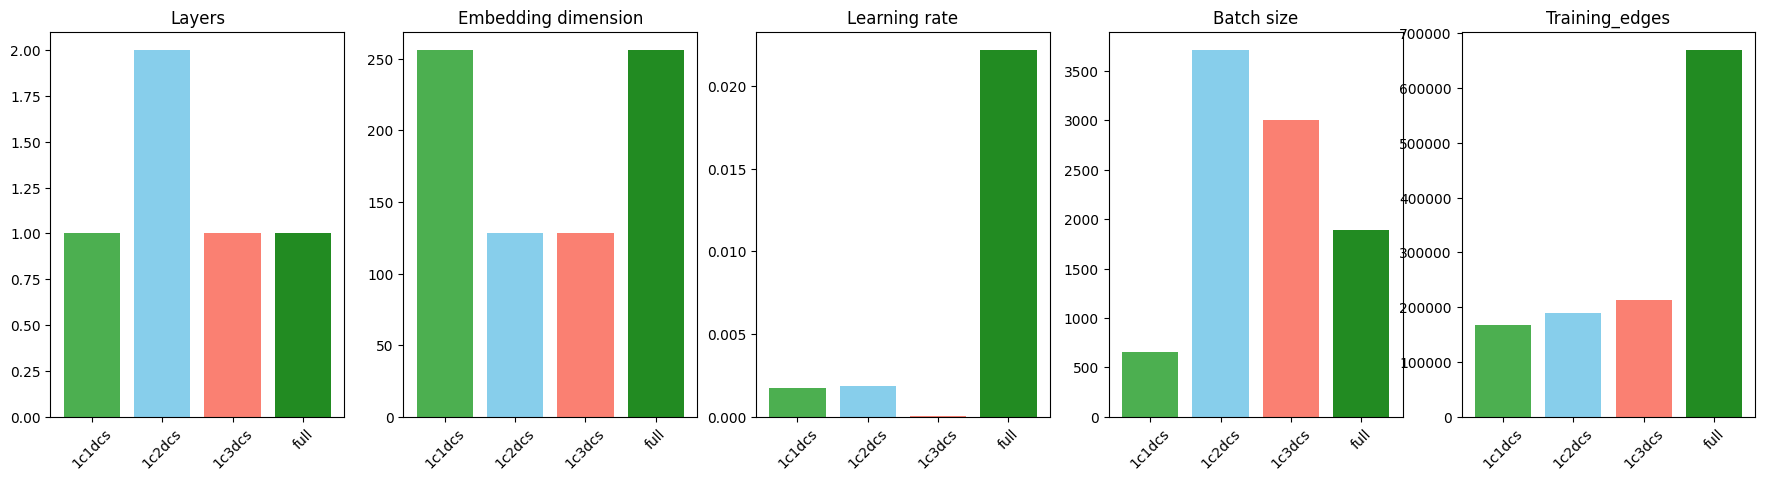

In [12]:
plots=['n_layers','embedding_dim','lr','batch_size','train_edges']
titles=['Layers', 'Embedding dimension', 'Learning rate', 'Batch size','Training_edges']
colors=[ '#4CAF50','skyblue','salmon','forestgreen']
plt.figure(figsize=(22,5))

cols = ['n_layers','embedding_dim','lr','batch_size']

config_values = result_viewable[~result_viewable['experiment'].str.contains('_rand')][['experiment']+plots]

for col in cols:
    config_values[col] = config_values[col].apply(lambda x: x[0])

for i,metric in enumerate(plots):
    plt.subplot(1,len(plots),i+1)

    plt.bar(config_values['experiment'], config_values[metric], color=colors, capsize=5)
    plt.title(titles[i])
    plt.xticks(rotation=45)

plt.show()
